In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
device = 'cpu'

In [3]:
words = open("names.txt", "r").read().splitlines()
print(words[:8])
print(len(words))

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']
32033


In [4]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [5]:
# build the dataset
block_size = 3 #  context lengthL how many characters do we take to predict the next one

def build_dataset(words):
    X, Y = [], []
    for w in words:
        
        # print(w)
        context = [0] * block_size
        for ch in w + '.':
            ix= stoi[ch]
            X.append(context)
            Y.append(ix)
            # print(''.join(itos[i] for i in context), '---->', itos[ix])
            context = context[1:] + [ix] # crop and append
            
    X = torch.tensor(X, device=device)
    Y = torch.tensor(Y, device=device)
    print(X.shape, Y.shape)
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))
Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [6]:
# utility function used later to compare manual gradients to pytorch gradients

def cmp(s, dt, t):
    ex = torch.all(dt == t.grad).item()
    app = torch.allclose(dt, t.grad)
    maxdiff = (dt - t.grad).abs().max().item()
    print(f'{s:15s} | exact: {str(ex):5s} | approximate: {str(app):5s} | maxdiff: {maxdiff}')

In [7]:
n_embed = 10
n_hidden = 64

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, n_embed), generator=g)

# Layer1
w1 = torch.randn((n_embed*block_size, n_hidden), generator=g) *(5/3) / ((n_embed * block_size)**0.5)
b1 = torch.randn((n_hidden), generator=g) *0.1

# Layer2
w2 = torch.randn((n_hidden, vocab_size), generator=g) *0.1
b2 = torch.randn((vocab_size), generator=g)*0.1

#batchnorm
bngain = torch.randn((1,n_hidden))*0.1 + 1.0
bnbias = torch.randn((1, n_hidden))*0.1

parameters = [C, w1, b1, w2, b2, bngain, bnbias]
print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad=True

4137


In [8]:
batch_size = 32
n = batch_size

# construct a mini batch
ix = torch.randint(0, Xtr.shape[0], (batch_size, ), generator=g)
Xb, Yb = Xtr[ix], Ytr[ix] # batch X, Y

In [9]:
# forward pass, in smaller steps that are possible to backward one at a time

emb = C[Xb]
embcat = emb.view(emb.shape[0], -1) # concatenate the vectors

# Linear layer 1
hprebn = embcat @ w1 + b1

# BatchNorm layer
bnmeani = 1/n*hprebn.sum(0, keepdim=True)
bndiff = hprebn - bnmeani
bndiff2 = bndiff**2
bnvar = 1/(n-1)*(bndiff2).sum(0, keepdim=True) # bessels correction( dividing by n-1, not n)
bnvar_inv = (bnvar + 1e-5)**-0.5 
bnraw = bndiff * bnvar_inv
hpreact = bngain * bnraw + bnbias

# non linearity
h = torch.tanh(hpreact) # hidden layer

# Linear layer 2
logits = h @ w2 + b2

# cross entropu loss
logits_maxes = logits.max(1, keepdim=True).values
norm_logits = logits - logits_maxes # subtract max for numerical stability
counts = norm_logits.exp()
counts_sum = counts.sum(1, keepdim=True)
counts_sum_inv = counts_sum**-1
probs = counts * counts_sum_inv
logprobs = probs.log()
loss = -logprobs[range(n), Yb].mean()

# Pytorch backward pass
for p in parameters:
    p.grad = None
for t in [logprobs, probs,counts, counts_sum, counts_sum_inv,
          norm_logits, logits_maxes, logits, h, hpreact, bnraw,
          bnvar_inv, bnvar, bndiff2, bndiff, hprebn, bnmeani,
          embcat, emb]:
    t.retain_grad()
loss.backward()
loss

tensor(3.3251, grad_fn=<NegBackward0>)

In [20]:
# Excercise1: backprob through forwar pass variables

dlogprobs = torch.zeros_like(logprobs)
dlogprobs[range(n), Yb] = -1.0 / n
dprobs =   (1.0/ probs) * dlogprobs
dcountsum_inv = (dprobs *  counts).sum(1, keepdim=True)
dcounts = counts_sum_inv * dprobs
dcountsum = dcountsum_inv * (-counts_sum**-2)
dcounts += torch.ones_like(counts) * dcountsum
dnorm_logits = (norm_logits.exp()) * dcounts
dlogits = dnorm_logits.clone()
dlogit_maxes = (-dnorm_logits).sum(1, keepdim=True)
dlogits += F.one_hot(logits.max(1).indices, num_classes=logits.shape[1])*dlogit_maxes
dh = dlogits @ w2.T
dw2 = h.T @ dlogits
db2 = dlogits.sum(0)
dhpreact = (1.0 - h**2) * dh
dbngain = (bnraw * dhpreact).sum(0, keepdim=True)
dbnraw = bngain * dhpreact
dbnbias = dhpreact.sum(0, keepdim=True)
dbndiff = bnvar_inv * dbnraw
dbnvar_inv = (bndiff * dbnraw).sum(0, keepdim=True)
dbnvar = (-0.5 * (bnvar + 1e-5)**-1.5) * dbnvar_inv
dbndiff2 = (torch.ones_like(bndiff2)* (1/(n-1)) * dbnvar)
dbndiff += 2 * bndiff * dbndiff2
dhprebn = dbndiff.clone()
dbnmeani = (-dbndiff).sum(0)
dhprebn += (torch.ones_like(hprebn)* (1/n)) * dbnmeani
dw1 = embcat.T @ dhprebn
db1 = dhprebn.sum(0)
dembcat = dhprebn @ w1.T
demb = dembcat.view(emb.shape)
dC = torch.zeros_like(C)
for k in range(Xb.shape[0]):
    for j in range(Xb.shape[1]):
        ix = Xb[k,j]
        dC[ix] += demb[k,j]

cmp('logprobs', dlogprobs, logprobs)
cmp('probs', dprobs, probs)
cmp('countsu_inv', dcountsum_inv, counts_sum_inv)
cmp('countsum', dcountsum, counts_sum)
cmp('counts', dcounts, counts)
cmp('norm_logits', dnorm_logits, norm_logits)
cmp('logits', dlogits, logits)
cmp('logits_maxes', dlogit_maxes, logits_maxes)
cmp('h', dh, h)
cmp('w2', dw2, w2)
cmp('b2', db2, b2)
cmp('hpreact', dhpreact, hpreact)
cmp('bngain', dbngain, bngain)
cmp('bnraw', dbnraw, bnraw)
cmp('bnbias', dbnbias, bnbias)
cmp('bndiff', dbndiff, bndiff)
cmp('bnvar_inv', dbnvar_inv, bnvar_inv)
cmp('bnvar', dbnvar, bnvar) 
cmp('bndiff2', dbndiff2, bndiff2)
cmp('hprebn', dhprebn, hprebn)
cmp('bnmeani', dbnmeani, bnmeani)
cmp('w1', dw1, w1)
cmp('b1', db1, b1)
cmp('embcat', dembcat, embcat)
cmp('emb', demb, emb)
cmp('C', dC, C)

logprobs        | exact: True  | approximate: True  | maxdiff: 0.0
probs           | exact: True  | approximate: True  | maxdiff: 0.0
countsu_inv     | exact: True  | approximate: True  | maxdiff: 0.0
countsum        | exact: True  | approximate: True  | maxdiff: 0.0
counts          | exact: True  | approximate: True  | maxdiff: 0.0
norm_logits     | exact: True  | approximate: True  | maxdiff: 0.0
logits          | exact: True  | approximate: True  | maxdiff: 0.0
logits_maxes    | exact: True  | approximate: True  | maxdiff: 0.0
h               | exact: True  | approximate: True  | maxdiff: 0.0
w2              | exact: True  | approximate: True  | maxdiff: 0.0
b2              | exact: True  | approximate: True  | maxdiff: 0.0
hpreact         | exact: False | approximate: True  | maxdiff: 4.656612873077393e-10
bngain          | exact: False | approximate: True  | maxdiff: 1.862645149230957e-09
bnraw           | exact: False | approximate: True  | maxdiff: 9.313225746154785e-10
bnbias  

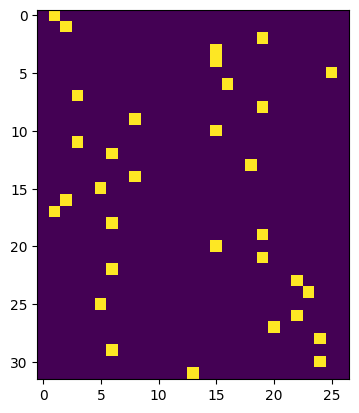

In [24]:
plt.imshow(F.one_hot(logits.max(1).indices, num_classes=logits.shape[1]));

In [21]:
# Exercise 2: backprop through cross-entropy but all in one go


loss_fast = F.cross_entropy(logits, Yb)
print(loss_fast.item(), 'diff: ', (loss_fast - loss).item())

3.325113296508789 diff:  2.384185791015625e-07


In [22]:
# backward pass

dlogits = F.softmax(logits, 1)
dlogits[range(n), Yb] -= 1
dlogits /= n

cmp('logitsm', dlogits, logits)

logitsm         | exact: False | approximate: True  | maxdiff: 7.916241884231567e-09


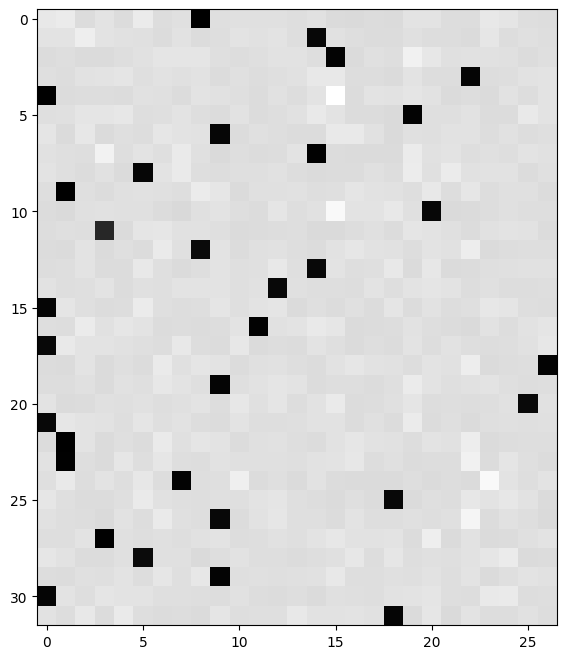

In [25]:
plt.figure(figsize=(8,8))
plt.imshow(dlogits.detach(), cmap='gray');

In [ ]:
# Exercise 3: batchnorm through batchnorm but all in one go

# before 
# dbngain = (bnraw * dhpreact).sum(0, keepdim=True)
# dbnraw = bngain * dhpreact
# dbnbias = dhpreact.sum(0, keepdim=True)
# dbndiff = bnvar_inv * dbnraw
# dbnvar_inv = (bndiff * dbnraw).sum(0, keepdim=True)
# dbnvar = (-0.5 * (bnvar + 1e-5)**-1.5) * dbnvar_inv
# dbndiff2 = (torch.ones_like(bndiff2)* (1/(n-1)) * dbnvar)
# dbndiff += 2 * bndiff * dbndiff2
# dhprebn = dbndiff.clone()
# dbnmeani = (-dbndiff).sum(0)
# dhprebn += (torch.ones_like(hprebn)* (1/n)) * dbnmeani


